## Error budgeted QSVT Framework

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Poisson1D import (Poisson1DFD,
                       get1Dconvergence, plot_convergence, test_spectral_cutoff_impact, 
                       mesh_independence_study,plot_mesh_independence, point_load_independence_study)


from BudgetedQSVT import BudgetedSigmaQSVT

## Create 1D Finite Difference Poisson

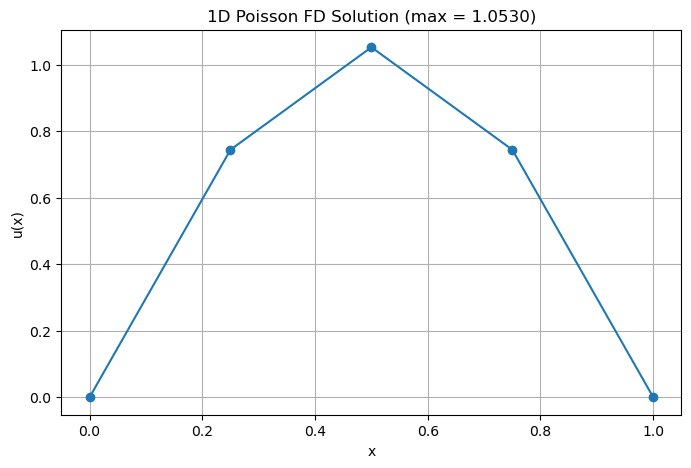

In [2]:
nElements = 2**2
h = 1.0/nElements
poisson1DFD = Poisson1DFD(n_elements=nElements)
u1D = poisson1DFD.solve() # classical solve
poisson1DFD.plot_solution(u1D)

## Spectral test

In [3]:
test_spectral_cutoff_impact()


--- Spectral Analysis & Error Budget (n=64) ---
Modes: Low (k=1), Med (k=3), High (k=5)
FEA Floor Error (eps_fea):     8.90e-03
Truncation Error (eps_sigma):  5.79e-14
Spectrum Discarded:            79.4%
Effective Condition Number:    165.94 (vs 1659.38 full)


## Mesh independence study

n= 16 | Full Kappa:    103.1 | Eff Kappa:   1.0 | Savings:  93.3%
n= 32 | Full Kappa:    414.3 | Eff Kappa:   1.0 | Savings:  96.8%
n= 64 | Full Kappa:   1659.4 | Eff Kappa:   1.0 | Savings:  98.4%
n=128 | Full Kappa:   6639.5 | Eff Kappa:   1.0 | Savings:  99.2%
n=256 | Full Kappa:  26560.1 | Eff Kappa:   1.0 | Savings:  99.6%
n=512 | Full Kappa: 106242.3 | Eff Kappa:   1.0 | Savings:  99.8%


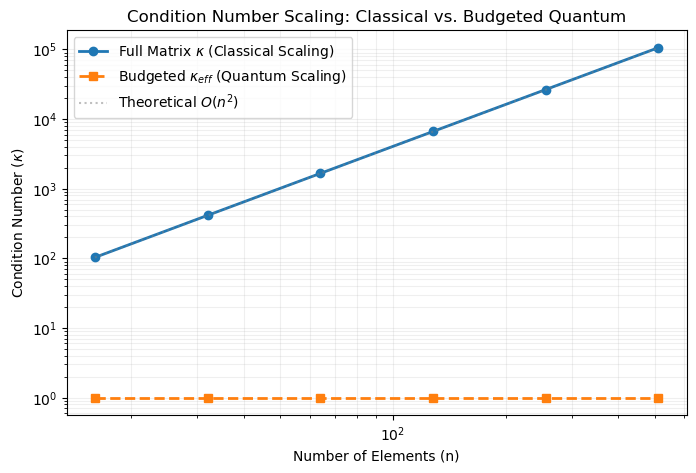

In [4]:
results = mesh_independence_study()
plot_mesh_independence(results)

## Point load

n= 32 | Full Kappa:    414.3 | Eff Kappa: 390.8 | Savings:  12.9%
n= 64 | Full Kappa:   1659.4 | Eff Kappa: 475.2 | Savings:  63.5%
n=128 | Full Kappa:   6639.5 | Eff Kappa: 431.3 | Savings:  83.5%
n=256 | Full Kappa:  26560.1 | Eff Kappa: 438.6 | Savings:  91.8%
n=512 | Full Kappa: 106242.3 | Eff Kappa: 440.4 | Savings:  95.9%


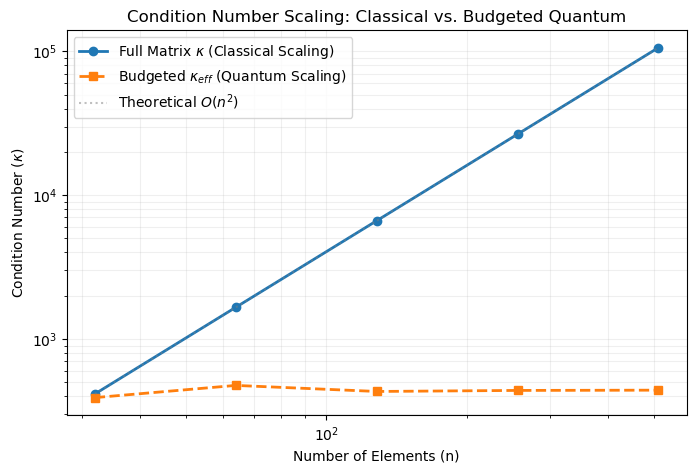

In [5]:
results = point_load_independence_study()
plot_mesh_independence(results)

## Main Budgeted QSVT Solver

Optimal degree for ε=1.00e-02: 205
Polynomial maximum: 35.4754
After normalization, max value: 0.997744
Solving Poisson N=8 with Budgeted Kappa=3.24
Running QSVT circuit on statevector simulator...


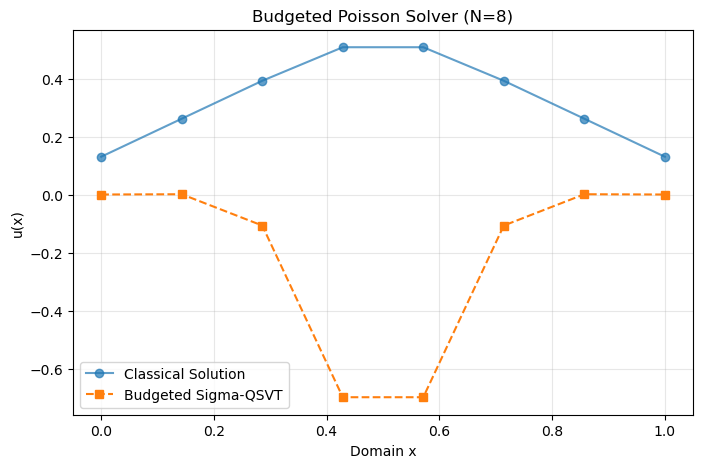

Fidelity: 0.6313


In [8]:

# 1. Setup Parameters
m = 3
n = 2**m
x = np.linspace(0, 1, n)

# 2. Define a "Budgeted" Point Load
# Gaussian pulse centered at 0.5
b = np.exp(-(x - 0.5)**2 / (2 * 0.1**2))
b /= np.linalg.norm(b) 

# 3. Define Spectral Bounds (from your scaling study)
# Smallest eigenvalue for Poisson
sigma_min = (np.pi / n)**2 
# Budgeted plateau (kappa_eff approx 440 in your plot, but scaled for N=8 here)
sigma_cut = 0.5 
kappa_eff = sigma_cut / sigma_min

# 4. Initialize Solver
# This uses the SigmaBasisBlockEncoding we integrated earlier
solver = BudgetedSigmaQSVT(
    m=m, 
    b=b, 
    sigma_min=sigma_min, 
    sigma_cut=sigma_cut, 
    target_error=1e-2
)

# 5. Solve
print(f"Solving Poisson N={n} with Budgeted Kappa={kappa_eff:.2f}")
u_quantum = solver.solve(stateVector=True)

# 6. Verification
A_full = solver.encoder.get_full_matrix() * solver.encoder.alpha
u_classical = np.linalg.solve(A_full, b)
u_classical /= np.linalg.norm(u_classical)

# 7. Plotting
plt.figure(figsize=(8, 5))
plt.plot(x, u_classical, 'o-', label='Classical Solution', alpha=0.7)
plt.plot(x, u_quantum.real, 's--', label='Budgeted Sigma-QSVT')
plt.title(f"Budgeted Poisson Solver (N={n})")
plt.xlabel("Domain x")
plt.ylabel("u(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Fidelity: {np.abs(np.dot(u_quantum.conj(), u_classical))**2:.4f}")